# <center> AI 1013 : Programming for AI </center>
## <center> Assignment 2 </center>

### 1 Training an Artificial Neural Network

#### 1.1 Dataset Preparation

Loading the dataset

In [1]:
import pandas as pd
dataset = pd.read_csv("data_Q1.csv")
dataset.head(3)

,x1,x2,y
0,0.982446,1.006009,0
1,0.996514,0.988684,0
2,-0.001926,1.006868,1


Converting dataframe columns to numpy arrays

In [2]:
training_x1 = dataset["x1"].to_numpy()
training_x2 = dataset["x2"].to_numpy()
training_y = dataset["y"].to_numpy()
N = len(training_x1)


import numpy as np
training_x = np.array([[x1,x2,1] for x1,x2 in zip(training_x1, training_x2)])

#### 1.3 Definitons and Initialisations

Setting fixed seed

In [3]:
np.random.seed(123)

Defining the sigmoid function 
\begin{align}
\sigma(x) = \frac{1}{1+e^{-x}}
\end{align}

In [4]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

Defining the grad_sigmoid function
\begin{align}
\frac{d}{dx} (\frac{1}{1+e^{-x}}) &= \frac{e^{-x}}{(1+e^{-x})^2} \\
\frac{d}{dx} \left( \sigma (x) \right) &= \sigma(x) \left(1-\sigma(x)\right)
\end{align}

In [5]:
def grad_sigmoid(x):
    return sigmoid(x)*(1-sigmoid(x))

Intializing $W^{(1)}$

In [6]:
a = -1
b = 1
weights1 = np.zeros((3,3))
for i in range(0,3):
    for j in range(0,3):
        weights1[i][j] = a + np.random.rand()*(b-a)
weights1

array([[ 0.39293837, -0.42772133, -0.54629709],
       [ 0.10262954,  0.43893794, -0.15378708],
       [ 0.9615284 ,  0.36965948, -0.0381362 ]])

Initializing $W^{(2)}$

In [7]:
a = -1
b = 1
weights2 = np.zeros(4)
for i in range(0,4):
    weights2[i] = a + np.random.rand()*(b-a)
weights2

array([-0.21576496, -0.31364397,  0.45809941, -0.12285551])

Initialzing the learning rate $(\gamma)$ and `max_epochs`

In [8]:
learning_rate = 0.05
max_epochs = 100
N = len(training_x)

Array to store training errors

In [9]:
training_error = []

#### 1.4 Training the Neural Network

In [10]:
for _ in range(max_epochs):

    '''
    FORWARD PASS
    '''
    #setting the input X as training data
    X = training_x

    #hidden layer input
    H = X @ weights1

    #applying sigmoid function to the inputs of hidden layer
    Z = sigmoid(H)

    #appeding a column of all ones for the bias
    all_ones_column = np.ones((200,1))
    Z = np.hstack((Z, all_ones_column))

    #Output layer input
    O = Z @ weights2
    O = np.squeeze(O)

    #applying sigmoid fn to the input of the output layer
    predicted_y = sigmoid(O)
    predicted_y = np.squeeze(predicted_y)

    #calculating the training error and appending it to our array
    #using the formula mean-squared-error = (1/2)*mean_squared_loss
    loss = np.mean((training_y - predicted_y)**2)/2
    training_error.append(loss)


    '''
    BACK PROPAGATION
    '''
    #Calculating gradient2
    #Clculations attached
    gradient2 = (Z.T @ ((predicted_y - training_y) * grad_sigmoid(O))) / N


    #Calculating gradient1
    #Cakculations attached
    gradient1 = (training_x.T @ (((predicted_y - training_y) * grad_sigmoid(O))[:,None] * grad_sigmoid(H) * weights2[:-1])) / N


    #Updating the weights
    weights2 = weights2 - learning_rate*gradient2
    weights1 = weights1 - learning_rate*gradient1

Plotting the Training Loss

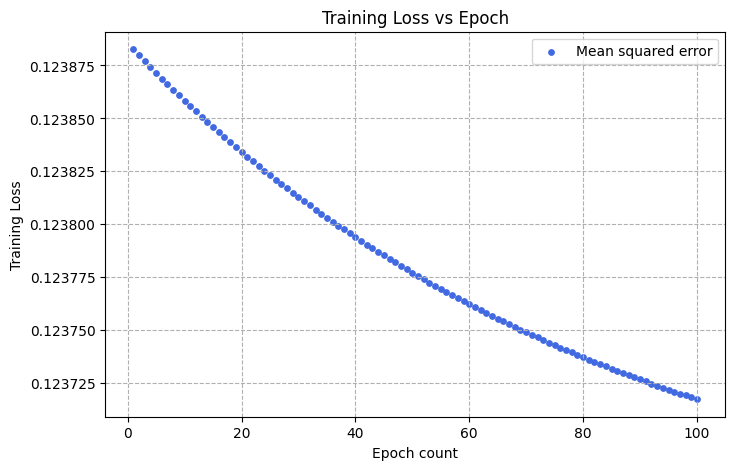

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(range(1,101), training_error, label="Mean squared error", color ="royalblue", s=15)

plt.xlabel("Epoch count")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(linestyle="--")
plt.legend()
plt.show()